<a href="https://colab.research.google.com/github/muhammedali123-collab/pakistan-banking-dataset/blob/main/Pakistan_Banking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pakistan Banking Dataset

#Data Loading

In [1]:
from google.colab import files
uploaded =files.upload()

Saving pakistan_banking_dataset.csv to pakistan_banking_dataset.csv


In [2]:
#Import some basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
dataali = pd.read_csv('pakistan_banking_dataset.csv')
#Using data.head() we can see the top 5 rows of the dataset

#Exploratory Data Analysis

In [4]:
dataali.shape

(6000, 10)

In [5]:
dataali.head(5)

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type,Churn
0,1,56,Female,Karachi,UBL,1214138,No,455,Current,0
1,2,69,Female,Lahore,Allied Bank,1860696,No,682,Savings,0
2,3,46,Female,Faisalabad,UBL,1681369,Yes,619,Current,1
3,4,32,Male,Faisalabad,HBL,60650,No,672,Savings,1
4,5,60,Female,Lahore,Allied Bank,1727765,Yes,830,Savings,0


In [6]:
dataali.tail(3)

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type,Churn
5997,5998,44,Female,Lahore,Allied Bank,542374,Yes,618,Current,1
5998,5999,26,Male,Faisalabad,Meezan Bank,990086,No,410,Current,0
5999,6000,64,Male,Faisalabad,Allied Bank,895641,Yes,772,Current,1


In [7]:
dataali.describe()

,Customer_ID,Age,Account_Balance_PKR,Credit_Score,Churn
count,6000.000000,6000.000000,6.000000e+03,6000.000000,6000.000000
mean,3000.500000,43.677500,1.003041e+06,600.778667,0.513833
std,1732.195139,14.913872,5.777341e+05,173.982238,0.499850
min,1.000000,18.000000,1.005600e+04,300.000000,0.000000
25%,1500.750000,31.000000,5.069218e+05,450.000000,0.000000
50%,3000.500000,44.000000,1.005330e+06,604.000000,1.000000
75%,4500.250000,56.000000,1.507488e+06,753.000000,1.000000
max,6000.000000,69.000000,1.999572e+06,899.000000,1.000000


In [8]:
dataali.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          6000 non-null   int64 
 1   Age                  6000 non-null   int64 
 2   Gender               6000 non-null   object
 3   City                 6000 non-null   object
 4   Bank_Name            6000 non-null   object
 5   Account_Balance_PKR  6000 non-null   int64 
 6   Loan_Status          6000 non-null   object
 7   Credit_Score         6000 non-null   int64 
 8   Account_Type         6000 non-null   object
 9   Churn                6000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 468.9+ KB


In [9]:
dataali.iloc[:, :-1]

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type
0,1,56,Female,Karachi,UBL,1214138,No,455,Current
1,2,69,Female,Lahore,Allied Bank,1860696,No,682,Savings
2,3,46,Female,Faisalabad,UBL,1681369,Yes,619,Current
3,4,32,Male,Faisalabad,HBL,60650,No,672,Savings
4,5,60,Female,Lahore,Allied Bank,1727765,Yes,830,Savings
...,...,...,...,...,...,...,...,...,...
5995,5996,55,Female,Rawalpindi,UBL,1283452,Yes,870,Current
5996,5997,61,Female,Islamabad,Allied Bank,470153,Yes,638,Current
5997,5998,44,Female,Lahore,Allied Bank,542374,Yes,618,Current
5998,5999,26,Male,Faisalabad,Meezan Bank,990086,No,410,Current


In [10]:
dataali.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
City,0
Bank_Name,0
Account_Balance_PKR,0
Loan_Status,0
Credit_Score,0
Account_Type,0
Churn,0


#Data Preprocessing

In [11]:
dataali['Gender'].value_counts()

,count
Gender,
Female,3025
Male,2975


In [12]:
dataali['Gender'] = dataali['Gender'].str.strip().str.title()

#Numerical

In [13]:
dataali = pd.get_dummies(dataali, drop_first=True)

#Features & Target

In [14]:
X = dataali.drop('Churn', axis=1)   # target after encoding
y = dataali['Churn']

#Data Visualization

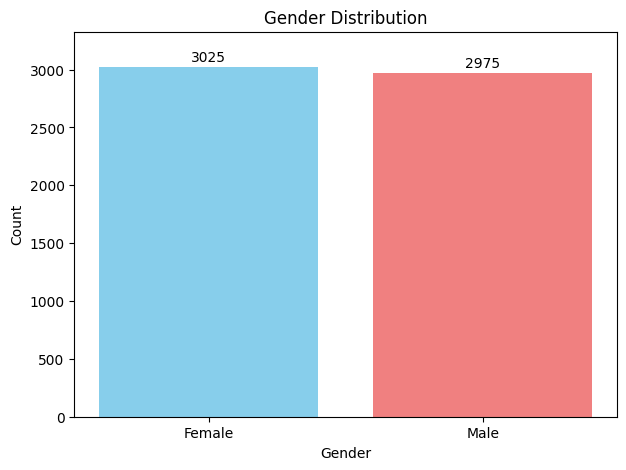

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# The original 'Gender' column no longer exists after pd.get_dummies
# Instead, we use the 'Gender_Male' column and map it back to 'Female' and 'Male'
gender_male_counts = dataali['Gender_Male'].value_counts()

# Create a Series with 'Female' and 'Male' as index for plotting
gender_counts = pd.Series(
    [gender_male_counts.get(False, 0), gender_male_counts.get(True, 0)],
    index=['Female', 'Male']
)

plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightcoral'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')

# Add count labels on top of the bars
for index, value in enumerate(gender_counts.values):
    plt.text(index, value + 20, str(value), ha='center', va='bottom') # Adjust +20 for better positioning

plt.ylim(0, max(gender_counts.values) * 1.1) # Adjust y-axis limit to accommodate labels
plt.show()

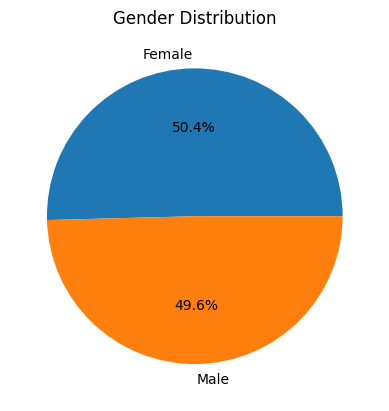

In [18]:
gender_male_counts = dataali['Gender_Male'].value_counts()

gender_counts = pd.Series(
    [gender_male_counts.get(False, 0), gender_male_counts.get(True, 0)],
    index=['Female', 'Male']
)

plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

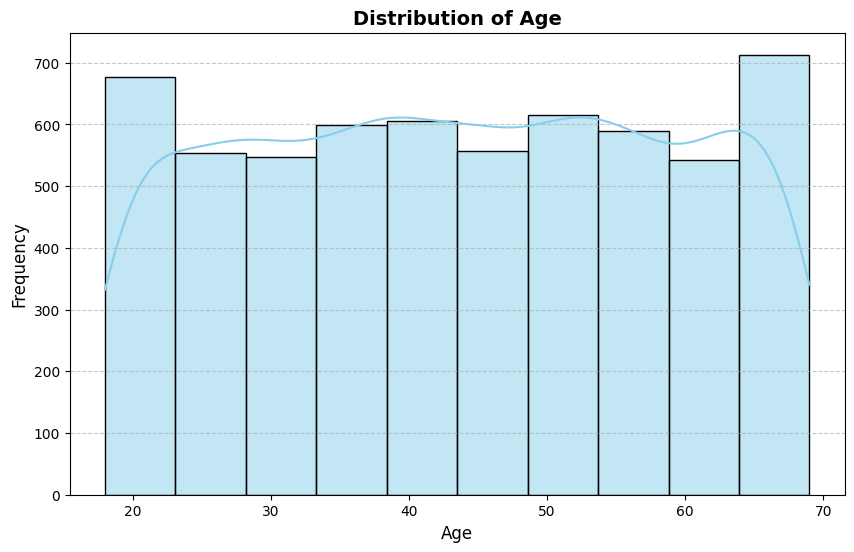

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) # Set a good figure size
sns.histplot(dataali['Age'], bins=10, kde=True, color='skyblue', edgecolor='black') # Using seaborn's histplot
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Age', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

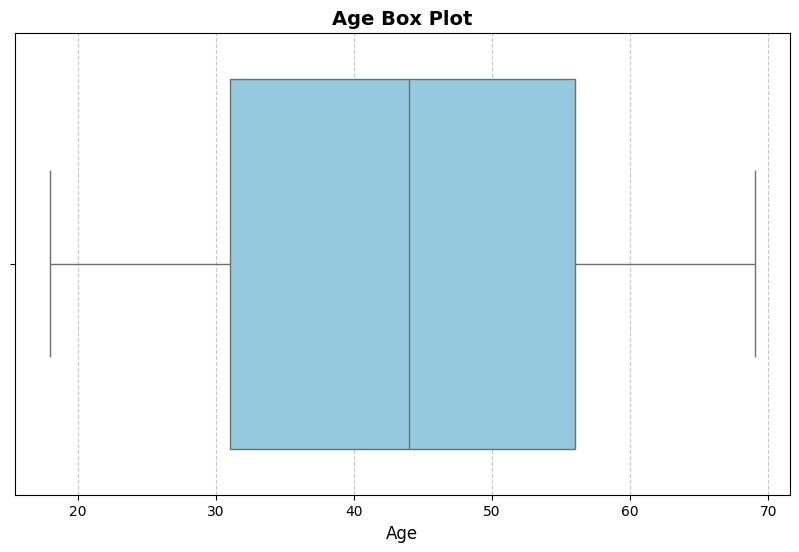

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) # Set a good figure size
sns.boxplot(x=dataali['Age'], color='skyblue') # Changed palette to color for a single box plot
plt.title('Age Box Plot', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

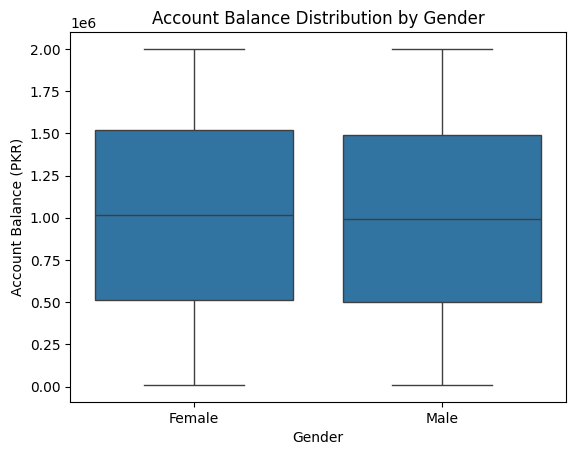

In [21]:
sns.boxplot(x='Gender_Male', y='Account_Balance_PKR', data=dataali)
plt.title('Account Balance Distribution by Gender')
plt.ylabel('Account Balance (PKR)')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Assuming 0 for Female and 1 for Male after get_dummies with drop_first=True
plt.xlabel('Gender') # Re-label the x-axis for clarity
plt.show()

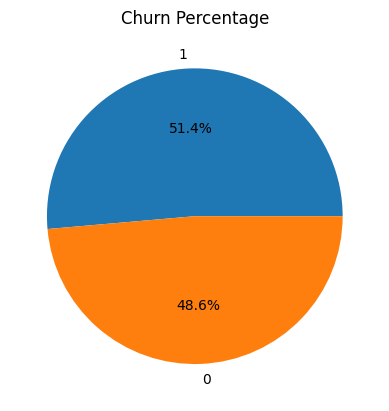

In [22]:
churn_counts = dataali['Churn'].value_counts()

plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%')
plt.title('Churn Percentage')
plt.show()

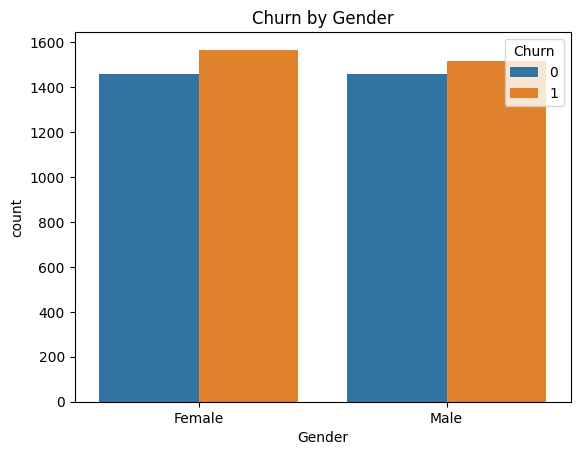

In [23]:
sns.countplot(x='Gender_Male', hue='Churn', data=dataali)
plt.title('Churn by Gender')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.xlabel('Gender')
plt.show()

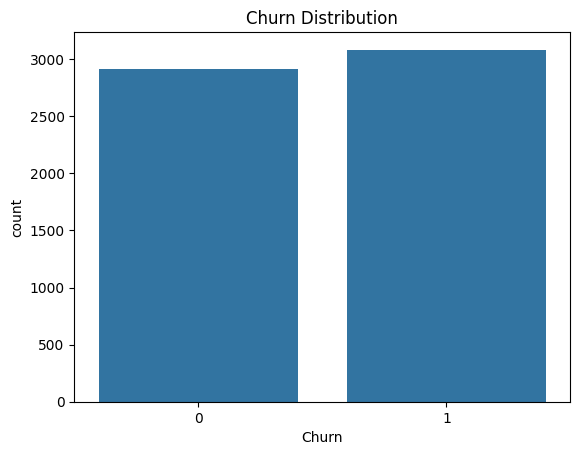

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=dataali)
plt.title('Churn Distribution')
plt.show()

#MACHINE LEARNING (TARGET CLASSIFICATION)

In [25]:
dataali.head(3)

,Customer_ID,Age,Account_Balance_PKR,Credit_Score,Churn,Gender_Male,City_Islamabad,City_Karachi,City_Lahore,City_Rawalpindi,Bank_Name_Bank Alfalah,Bank_Name_HBL,Bank_Name_Meezan Bank,Bank_Name_UBL,Loan_Status_Yes,Account_Type_Savings
0,1,56,1214138,455,0,False,False,True,False,False,False,False,False,True,False,False
1,2,69,1860696,682,0,False,False,False,True,False,False,False,False,False,False,True
2,3,46,1681369,619,1,False,False,False,False,False,False,False,False,True,True,False


In [26]:
#DECIDE  X, Y (X=TRAINING DATA , Y=TARGET DATA)

In [27]:
y = dataali["Churn"]

#Train Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
#library
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [30]:
x = dataali.drop("Churn", axis=1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
x=dataali.iloc[:, :-1]

In [32]:
x.head(2)

,Customer_ID,Age,Account_Balance_PKR,Credit_Score,Churn,Gender_Male,City_Islamabad,City_Karachi,City_Lahore,City_Rawalpindi,Bank_Name_Bank Alfalah,Bank_Name_HBL,Bank_Name_Meezan Bank,Bank_Name_UBL,Loan_Status_Yes
0,1,56,1214138,455,0,False,False,True,False,False,False,False,False,True,False
1,2,69,1860696,682,0,False,False,False,True,False,False,False,False,False,False


In [33]:
y=dataali.iloc[:,5]

In [34]:
y

,Gender_Male
0,False
1,False
2,False
3,True
4,False
...,...
5995,False
5996,False
5997,False
5998,True


In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [37]:
#verify
x_train.shape

(4800, 15)

In [38]:
x_test.shape

(1200, 15)

In [39]:
!pip install scikit-learn

In [40]:
!apt

apt 2.4.14 (amd64)
Usage: apt [options] command

apt is a commandline package manager and provides commands for
searching and managing as well as querying information about packages.
It provides the same functionality as the specialized APT tools,
like apt-get and apt-cache, but enables options more suitable for
interactive use by default.

Most used commands:
  list - list packages based on package names
  search - search in package descriptions
  show - show package details
  install - install packages
  reinstall - reinstall packages
  remove - remove packages
  autoremove - Remove automatically all unused packages
  update - update list of available packages
  upgrade - upgrade the system by installing/upgrading packages
  full-upgrade - upgrade the system by removing/installing/upgrading packages
  edit-sources - edit the source information file
  satisfy - satisfy dependency strings

See apt(8) for more information about the available commands.
Configuration options and syntax is

In [41]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
# Select only numerical columns for scaling.
# Note: 'Age' and 'Fare' may still be string type due to previous operations.
# You should ensure they are numerical and handle their missing values appropriately
# before scaling if you intend to include them.
numerical_cols = x_train.select_dtypes(include=np.number).columns
scaler.fit(x_train[numerical_cols])

StandardScaler()

In [42]:
Scaled_x_train=scaler.transform(x_train[numerical_cols])
Scaled_x_test=scaler.transform(x_test[numerical_cols])

In [43]:
Scaled_x_train

array([[ 1.56770502, -0.24406345,  0.58436453, -0.41143322, -1.02489307],
       [-0.84288458, -1.45152347,  1.22467958,  1.47469991, -1.02489307],
       [-0.10649187, -0.78071235, -0.12848763, -1.32854382, -1.02489307],
       ...,
       [ 1.20008578, -1.65276681,  1.57994432, -0.57870496, -1.02489307],
       [ 1.71890791, -0.17698233,  0.76010702, -0.64792086,  0.97571154],
       [-1.59832192, -1.51860458, -1.66157779, -0.78635264,  0.97571154]])

In [44]:
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#fit predict score

#1-KNN

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# Correctly defining x and y for a classification task based on the current dataset.

# 1. Define y as the target 'Churn'
y = dataali["Churn"]

# 2. Define x as features, dropping 'Customer_ID' and the target 'Churn'
x = dataali.drop(columns=["Customer_ID", "Churn"])

# 3. Numerical columns ('Age', 'Account_Balance_PKR', 'Credit_Score') are already in correct format (int64) and have no missing values.
#    No need for `pd.to_numeric` or `fillna` for these, unlike the original comments that were for a different dataset.

# 4. Handle categorical columns in x: 'Gender', 'City', 'Bank_Name', 'Loan_Status', 'Account_Type'
#    These were correctly identified as 'object' Dtype in dataali.info()
#    These columns have already been one-hot encoded by pd.get_dummies earlier, so LabelEncoding is not needed.
# le = LabelEncoder()
# x['Gender'] = le.fit_transform(x['Gender'])
# x['City'] = le.fit_transform(x['City'])
# x['Bank_Name'] = le.fit_transform(x['Bank_Name'])
# x['Loan_Status'] = le.fit_transform(x['Loan_Status'])
# x['Account_Type'] = le.fit_transform(x['Account_Type'])

# 5. Re-split data into training and testing sets with the corrected x and y
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 6. Scale numerical features (all features in x are now numerical after get_dummies and dropping non-numerical, or were already numerical)
scaler = StandardScaler()
Scaled_x_train = scaler.fit_transform(x_train) # Fit and transform on the new x_train
Scaled_x_test = scaler.transform(x_test) # Transform x_test using the scaler fitted on x_train

# Now, fit the KNN model using the scaled features and the correct target labels
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(Scaled_x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [46]:
y_pred_knn = knn.predict(Scaled_x_test)

In [47]:
accuracy_knn = knn.score(Scaled_x_test, y_test)
print("KNN Accuracy:", accuracy_knn, "%")

KNN Accuracy: 0.48083333333333333 %


#2-RANDOM FOREST

In [48]:
#library
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [49]:
RF = RandomForestClassifier()

RF.fit(Scaled_x_train, y_train)

RandomForestClassifier()

In [50]:
y_pred_rf = RF.predict(Scaled_x_test)

In [51]:
accuracy_rf = RF.score(Scaled_x_test, y_test)
print("Random Forest Accuracy:", accuracy_rf, "%")

Random Forest Accuracy: 0.49583333333333335 %


#3-loGISTIC REGRESSION

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
LF = LogisticRegression()

LF.fit(Scaled_x_train, y_train)

LogisticRegression()

In [54]:
y_pred = LF.predict(Scaled_x_test)

In [55]:
accuracy = LF.score(Scaled_x_test, y_test)
print("Accuracy:", accuracy, "%")

Accuracy: 0.49416666666666664 %


#4-DECISION TREE

In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
DT = DecisionTreeClassifier(random_state=42)

DT.fit(Scaled_x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [58]:
y_pred_dt = DT.predict(Scaled_x_test)

In [59]:
accuracy_dt = DT.score(Scaled_x_test, y_test)
print("Decision Tree Accuracy:", accuracy_dt, "%")

Decision Tree Accuracy: 0.5308333333333334 %


#5-DECISION TREE (Entropy Criterion)

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
DT_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

DT_entropy.fit(Scaled_x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [62]:
y_pred_dt_entropy = DT_entropy.predict(Scaled_x_test)

In [63]:
accuracy_dt_entropy = DT_entropy.score(Scaled_x_test, y_test)
print("Decision Tree (Entropy) Accuracy:", accuracy_dt_entropy, "%")

Decision Tree (Entropy) Accuracy: 0.5041666666666667 %


#6-EXTRA TREE CLASSIFIER

In [64]:
from sklearn.tree import ExtraTreeClassifier

In [65]:
ET = ExtraTreeClassifier(random_state=42)

ET.fit(Scaled_x_train, y_train)

ExtraTreeClassifier(random_state=42)

In [66]:
y_pred_et = ET.predict(Scaled_x_test)

In [67]:
accuracy_et = ET.score(Scaled_x_test, y_test)
print("Extra Tree Classifier Accuracy:", accuracy_et, "%")

Extra Tree Classifier Accuracy: 0.47583333333333333 %


## 7-Gaussian Naive Bayes

In [68]:
from sklearn.naive_bayes import GaussianNB

In [69]:
gnb = GaussianNB()

gnb.fit(Scaled_x_train, y_train)

GaussianNB()

In [70]:
y_pred_gnb = gnb.predict(Scaled_x_test)

In [71]:
accuracy_gnb = gnb.score(Scaled_x_test, y_test)
print("Gaussian Naive Bayes Accuracy:", accuracy_gnb, "%")

Gaussian Naive Bayes Accuracy: 0.49916666666666665 %


## 8-Passive Aggressive Classifier

In [72]:
from sklearn.linear_model import PassiveAggressiveClassifier

In [73]:
pac = PassiveAggressiveClassifier(random_state=42)
pac.fit(Scaled_x_train, y_train)

PassiveAggressiveClassifier(random_state=42)

In [74]:
y_pred_pac = pac.predict(Scaled_x_test)

In [75]:
accuracy_pac = pac.score(Scaled_x_test, y_test)
print("Passive Aggressive Classifier Accuracy:", accuracy_pac, "%")

Passive Aggressive Classifier Accuracy: 0.5308333333333334 %


## 9-Histogram-based Gradient Boosting

In [76]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [77]:
hgbc = HistGradientBoostingClassifier(random_state=42)
hgbc.fit(Scaled_x_train, y_train)

HistGradientBoostingClassifier(random_state=42)

In [78]:
y_pred_hgbc = hgbc.predict(Scaled_x_test)

In [79]:
accuracy_hgbc = hgbc.score(Scaled_x_test, y_test)
print("HistGradientBoostingClassifier Accuracy:", accuracy_hgbc, "%")

HistGradientBoostingClassifier Accuracy: 0.4841666666666667 %


## 10-Gradient Boosting

In [80]:
from sklearn.ensemble import GradientBoostingClassifier

In [81]:
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(Scaled_x_train, y_train)

GradientBoostingClassifier(random_state=42)

In [82]:
y_pred_gbc = gbc.predict(Scaled_x_test)

In [83]:
accuracy_gbc = gbc.score(Scaled_x_test, y_test)
print("Gradient Boosting Classifier Accuracy:", accuracy_gbc, "%")

Gradient Boosting Classifier Accuracy: 0.49333333333333335 %


## Model Accuracy Comparison

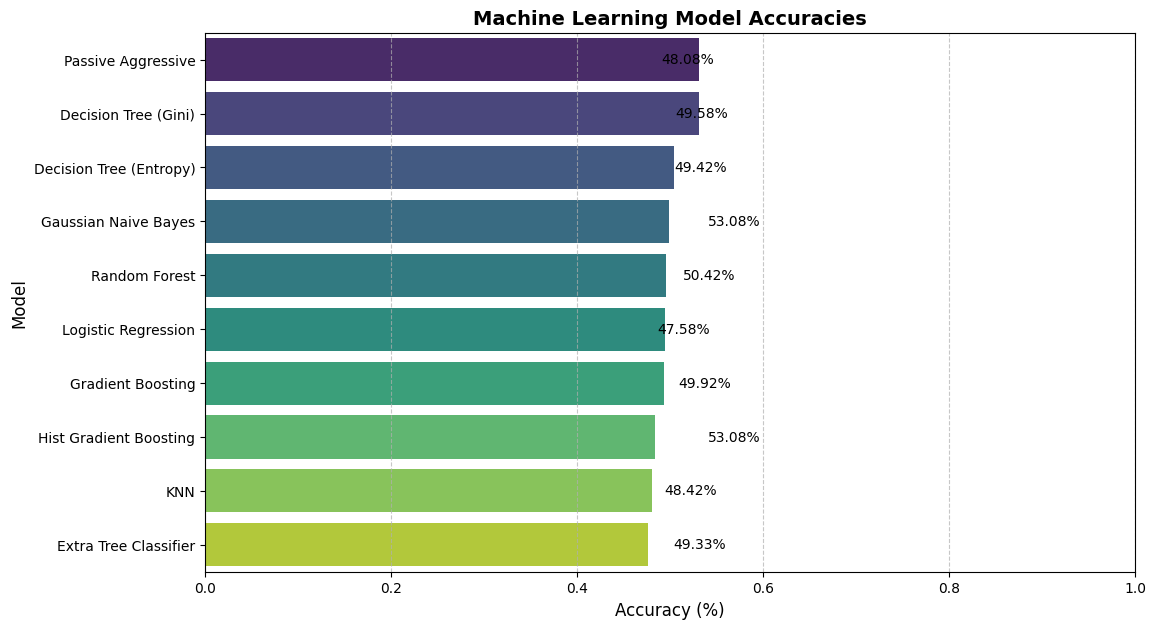

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

accuracies = {
    'KNN': accuracy_knn,
    'Random Forest': accuracy_rf,
    'Logistic Regression': accuracy,
    'Decision Tree (Gini)': accuracy_dt,
    'Decision Tree (Entropy)': accuracy_dt_entropy,
    'Extra Tree Classifier': accuracy_et,
    'Gaussian Naive Bayes': accuracy_gnb,
    'Passive Aggressive': accuracy_pac,
    'Hist Gradient Boosting': accuracy_hgbc,
    'Gradient Boosting': accuracy_gbc
}

accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, hue='Model', palette='viridis', legend=False)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.title('Machine Learning Model Accuracies', fontsize=14, fontweight='bold')
plt.xlim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on the bars
for index, row in accuracy_df.iterrows():
    plt.text(row.Accuracy + 0.01, index, f'{row.Accuracy:.2%}', va='center', ha='left')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Model Accuracy Comparison

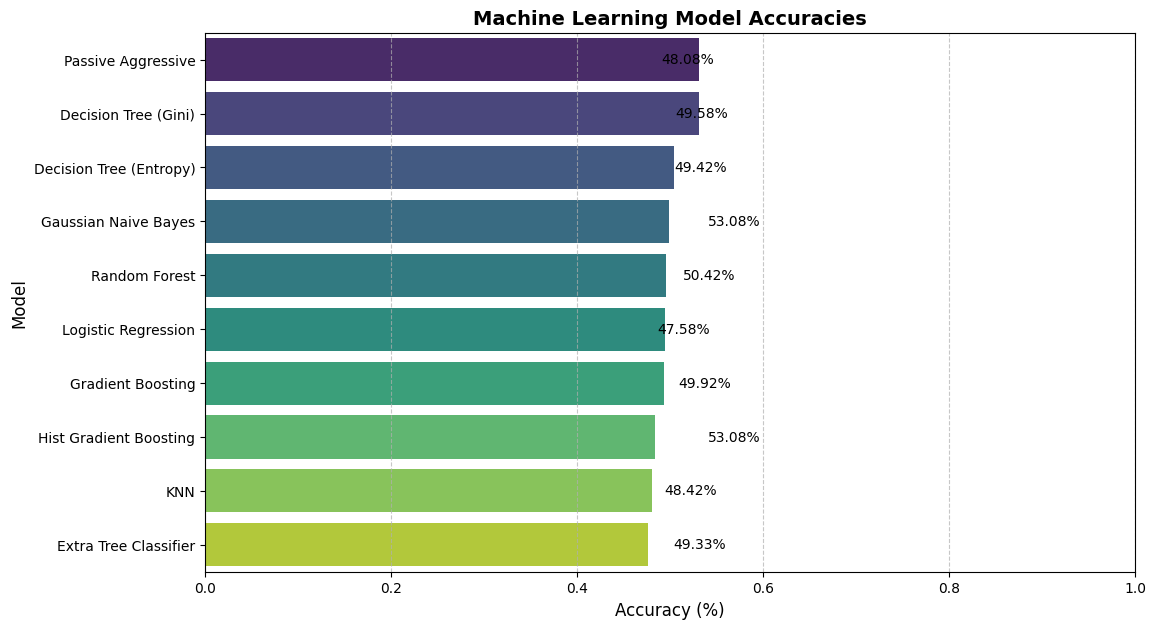

In [86]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

accuracies = {
    'KNN': accuracy_knn,
    'Random Forest': accuracy_rf,
    'Logistic Regression': accuracy,
    'Decision Tree (Gini)': accuracy_dt,
    'Decision Tree (Entropy)': accuracy_dt_entropy,
    'Extra Tree Classifier': accuracy_et,
    'Gaussian Naive Bayes': accuracy_gnb,
    'Passive Aggressive': accuracy_pac,
    'Hist Gradient Boosting': accuracy_hgbc,
    'Gradient Boosting': accuracy_gbc
}

accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, hue='Model', palette='viridis', legend=False)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.title('Machine Learning Model Accuracies', fontsize=14, fontweight='bold')
plt.xlim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on the bars
for index, row in accuracy_df.iterrows():
    plt.text(row.Accuracy + 0.01, index, f'{row.Accuracy:.2%}', va='center', ha='left')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()